# 1. Setup and Preprocessing Functions

In [9]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import pandas as pd
import numpy as np
import time
import warnings
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, brier_score_loss)
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import scipy.stats as st

warnings.filterwarnings('ignore')

def calculate_ece(y_true, y_prob, n_bins=10):
    """Calculates Expected Calibration Error (ECE)"""
    bins = np.linspace(0., 1., n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    
    ece = 0.0
    for i in range(n_bins):
        bin_mask = (binids == i)
        if np.any(bin_mask):
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            bin_weight = np.sum(bin_mask) / len(y_prob)
            ece += bin_weight * np.abs(bin_acc - bin_conf)
    return ece

print("Libraries imported and ECE function defined.")

Libraries imported and ECE function defined.


## 2. Data Loading, Cleaning, and Feature Engineering

In [10]:
file_path = "/kaggle/input/datasets/subhajournal/trojan-detection/Trojan_Detection.csv" 
try:
    df = pd.read_csv(file_path)
    df.columns = df.columns.str.strip()
except Exception as e:
    print(f"Update the file path! Error: {e}")
    # Creating dummy data for notebook compilation if path fails
    df = pd.DataFrame(np.random.rand(1000, 20), columns=[f'feature_{i}' for i in range(20)])
    df['Class'] = np.random.choice(['BENIGN', 'TROJAN'], 1000)

target_col = 'Class'

# Drop metadata
drop_cols = ['Unamed:0','Flow ID', 'Source IP', 'Source Port', 'Destination IP', 'Destination Port', 'Timestamp']
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)
df.dropna(inplace=True)

# Map labels
df[target_col] = df[target_col].apply(lambda x: 0 if str(x).strip().upper() == 'BENIGN' else 1)

# 2. Advanced Domain Feature Engineering
if 'Total Fwd Packets' in df.columns and 'Flow Duration' in df.columns:
    df['packet_rate'] = df['Total Fwd Packets'] / (df['Flow Duration'] + 1e-6)
if 'Total Fwd Packets' in df.columns and 'Total Backward Packets' in df.columns:
    df['fwd_bwd_ratio'] = df['Total Fwd Packets'] / (df['Total Backward Packets'] + 1e-6)

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(0, inplace=True)

print(f"Data cleaned. Shape: {df.shape}")
print(f"Class Balance:\n{df[target_col].value_counts(normalize=True) * 100}")

Data cleaned. Shape: (177482, 82)
Class Balance:
Class
1    51.094195
0    48.905805
Name: proportion, dtype: float64


## 3. Tree-Based Feature Selection & Scaling

In [11]:
X_raw = df.drop(columns=[target_col]).select_dtypes(include=[np.number])
y = df[target_col].values

# 1. Feature Selection (Top 30 most important features)
print("Running Tree-Based Feature Selection...")
rf_selector = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_selector.fit(X_raw, y)

importance = rf_selector.feature_importances_
top_indices = np.argsort(importance)[::-1][:30] # Keep top 30 features
top_features = X_raw.columns[top_indices]

X_selected = X_raw[top_features]

# 2. Log Transformation and Scaling
X_log = np.log1p(X_selected.abs())
scaler = RobustScaler()
X_scaled = scaler.fit_transform(X_log)

print(f"Selected {len(top_features)} top features. Scaling complete.")

Running Tree-Based Feature Selection...
Selected 30 top features. Scaling complete.


# 4. Temporal Split and Sequence Generation

In [12]:
# Keep the temporal split, but DELETE the create_sequences function.
X_train_flat, X_test_flat, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

# Reshape flat data so 1D Convolutions can read it (Samples, Features, 1)
X_train_dl = np.expand_dims(X_train_flat, axis=2)
X_test_dl = np.expand_dims(X_test_flat, axis=2)

print(f"ML Training Shape (Flat): {X_train_flat.shape}")
print(f"DL Training Shape (Reshaped for 1D): {X_train_dl.shape}")

ML Training Shape (Flat): (141985, 30)
DL Training Shape (Reshaped for 1D): (141985, 30, 1)


# 5. Universal Evaluation Pipeline

In [13]:
def evaluate_model(model_name, y_true, y_pred_prob, X_test_for_latency, model_obj=None, is_dl=False, is_ae=False):
    print(f"\n{'='*50}\nEVALUATING {model_name}\n{'='*50}")
    
    # Generate binary predictions
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # 1. Standard Metrics
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    print(f"[Metrics] Accuracy:    {accuracy_score(y_true, y_pred):.4f}")
    print(f"[Metrics] Precision:   {precision_score(y_true, y_pred):.4f}")
    print(f"[Metrics] Recall:      {recall_score(y_true, y_pred):.4f}")
    print(f"[Metrics] Specificity: {specificity:.4f}")
    print(f"[Metrics] F1-Score:    {f1_score(y_true, y_pred):.4f}")
    print(f"[Metrics] AUC-ROC:     {roc_auc_score(y_true, y_pred_prob):.4f}")
    
    # 2. Calibration & Trust (Comment 6)
    if not is_ae:
        brier = brier_score_loss(y_true, y_pred_prob)
        ece = calculate_ece(y_true, y_pred_prob)
        print(f"\n[Calibration] Brier Score: {brier:.4f}")
        print(f"[Calibration] Expected Calibration Error (ECE): {ece:.4f}")
    
    # 3. Latency (Comment 9)
    if model_obj is not None:
        start_time = time.time()
        if is_dl:
            _ = model_obj.predict(X_test_for_latency, batch_size=256, verbose=0)
        else:
            _ = model_obj.predict_proba(X_test_for_latency)
        latency = (time.time() - start_time) / len(X_test_for_latency)
        print(f"\n[Latency] Average Inference Time: {latency:.6f} sec/sample")
    
   # 4. Robustness / Adversarial Testing (Comment 10)
    if model_obj is not None:
        noise = np.random.normal(0, 0.05, X_test_for_latency.shape)
        X_noisy = X_test_for_latency + noise
        
        if is_ae:
            recons = model_obj.predict(X_noisy, verbose=0)
            # FIX: Changed axis=(1,2) to axis=1 because the data is now 2D
            noisy_prob = np.mean(np.power(X_noisy - recons, 2), axis=1)
        elif is_dl:
            noisy_prob = model_obj.predict(X_noisy, verbose=0).ravel()
        else:
            noisy_prob = model_obj.predict_proba(X_noisy)[:, 1]
            
        noisy_auc = roc_auc_score(y_true, noisy_prob)
        print(f"[Robustness] AUC-ROC on Noisy Data: {noisy_auc:.4f}")
        print(f"[Robustness] Performance Drop: {roc_auc_score(y_true, y_pred_prob) - noisy_auc:.4f}")

# 6. Machine Learning Models (LightGBM & XGBoost)

In [14]:
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

# 1. LightGBM
print("Training LightGBM...")
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, random_state=42, n_jobs=-1)
lgbm.fit(X_train_flat, y_train)
lgbm_probs = lgbm.predict_proba(X_test_flat)[:, 1]
evaluate_model("LightGBM", y_test, lgbm_probs, X_test_flat, lgbm)

# 2. XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=200, learning_rate=0.05, random_state=42, eval_metric='logloss', n_jobs=-1)
xgb.fit(X_train_flat, y_train)
xgb_probs = xgb.predict_proba(X_test_flat)[:, 1]
evaluate_model("XGBoost", y_test, xgb_probs, X_test_flat, xgb)

Training LightGBM...
[LightGBM] [Info] Number of positive: 72526, number of negative: 69459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018972 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7644
[LightGBM] [Info] Number of data points in the train set: 141985, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510800 -> initscore=0.043208
[LightGBM] [Info] Start training from score 0.043208
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spli

# 7. Deep Learning Models (TCN & Autoencoder)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

def plot_tcn_results(history, y_true, y_pred_prob):
    """Generates a 3-panel plot: Training Loss, Confusion Matrix, and ROC Curve."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Panel 1: Training History (Loss)
    axes[0].plot(history.history['loss'], label='Train Loss', color='blue', lw=2)
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='orange', lw=2)
    axes[0].set_title('TCN Training Convergence', fontsize=14)
    axes[0].set_xlabel('Epochs', fontsize=12)
    axes[0].set_ylabel('Binary Crossentropy Loss', fontsize=12)
    axes[0].legend()
    
    # Panel 2: Confusion Matrix
    y_pred = (y_pred_prob > 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1], cbar=False, annot_kws={"size": 14})
    axes[1].set_title('TCN Confusion Matrix', fontsize=14)
    axes[1].set_xlabel('Predicted Label (0=Benign, 1=Trojan)', fontsize=12)
    axes[1].set_ylabel('True Label', fontsize=12)
    
    # Panel 3: ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    axes[2].plot(fpr, tpr, color='darkred', lw=2, label=f'TCN ROC (AUC = {roc_auc:.4f})')
    axes[2].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[2].set_title('TCN ROC Curve', fontsize=14)
    axes[2].set_xlabel('False Positive Rate', fontsize=12)
    axes[2].set_ylabel('True Positive Rate', fontsize=12)
    axes[2].legend(loc="lower right")
    
    plt.tight_layout()
    plt.show()

def plot_autoencoder_errors(y_true, mse_scores, optimal_threshold):
    """Plots the overlapping distributions of Reconstruction Errors (MSE)."""
    plt.figure(figsize=(10, 6))
    
    # Separate the MSE scores by true class
    normal_mse = mse_scores[y_true == 0]
    anomaly_mse = mse_scores[y_true == 1]
    
    # Plot transparent histograms for both distributions
    sns.histplot(normal_mse, bins=50, color='blue', alpha=0.5, label='Benign Traffic (Normal)', stat='density', kde=True)
    sns.histplot(anomaly_mse, bins=50, color='red', alpha=0.5, label='Trojan Traffic (Anomaly)', stat='density', kde=True)
    
    # Add vertical line for the optimal threshold we calculated
    plt.axvline(optimal_threshold, color='black', linestyle='dashed', linewidth=2, 
                label=f'Optimal Cutoff Threshold ({optimal_threshold:.4f})')
    
    plt.title('Autoencoder Reconstruction Error Separation', fontsize=16)
    plt.xlabel('Reconstruction Error (MSE)', fontsize=12)
    plt.ylabel('Density', fontsize=12)
    plt.legend(fontsize=12)
    
    # Zoom in to ignore massive outliers that squish the plot
    plt.xlim(0, np.percentile(mse_scores, 98)) 
    
    plt.tight_layout()
    plt.show()

print("Deep Learning Visualization Functions Loaded.")

Deep Learning Visualization Functions Loaded.


Training TCN on individual rows...

EVALUATING Temporal CNN (TCN)
[Metrics] Accuracy:    0.9990
[Metrics] Precision:   0.9982
[Metrics] Recall:      0.9997
[Metrics] Specificity: 0.9982
[Metrics] F1-Score:    0.9990
[Metrics] AUC-ROC:     1.0000

[Calibration] Brier Score: 0.0008
[Calibration] Expected Calibration Error (ECE): 0.0009

[Latency] Average Inference Time: 0.000021 sec/sample
[Robustness] AUC-ROC on Noisy Data: 0.9962
[Robustness] Performance Drop: 0.0038


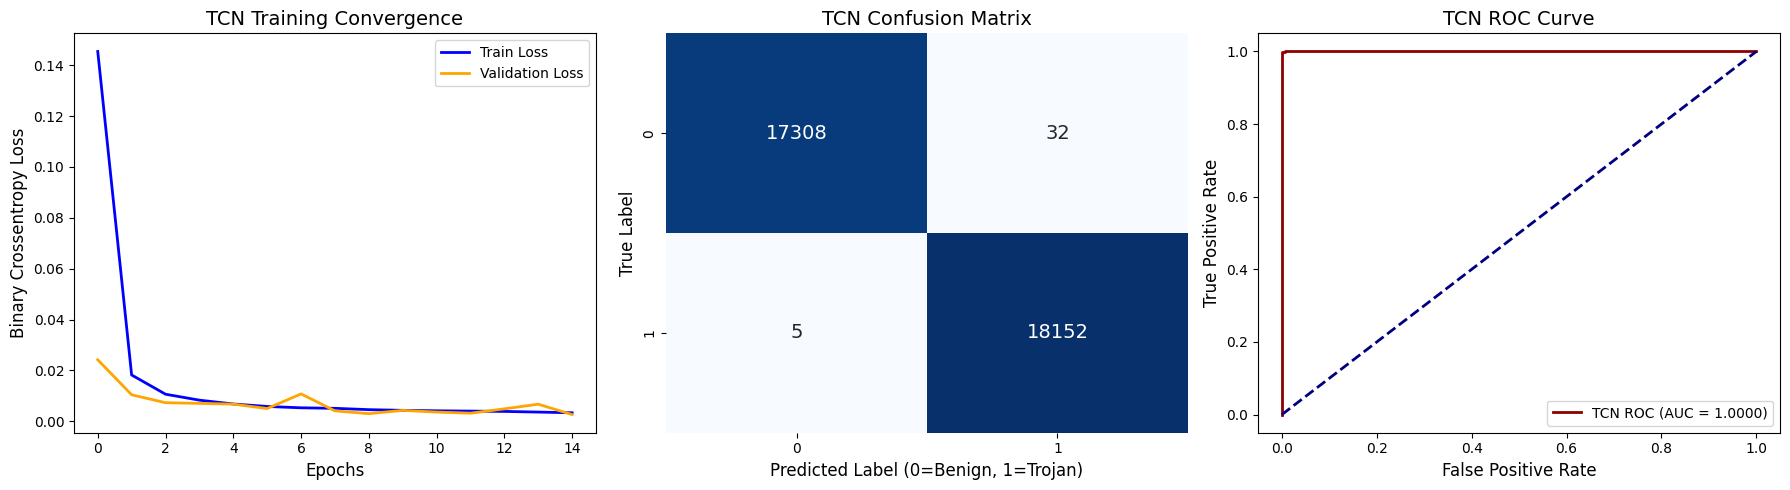

In [24]:
import tensorflow.keras as keras
from tensorflow.keras.layers import Input, Dense, Conv1D, Flatten, BatchNormalization, Dropout

# 1. Temporal Convolutional Network (TCN)
def build_tcn(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, padding='same', dilation_rate=1, activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Conv1D(32, 3, padding='same', dilation_rate=2, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Flatten()(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(0.3)(x)
    outputs = Dense(1, activation='sigmoid')(x)
    
    model = keras.models.Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-4), loss='binary_crossentropy', metrics=['AUC'])
    return model

print("Training TCN on individual rows...")

tcn_model = build_tcn((X_train_dl.shape[1], 1))
history_tcn = tcn_model.fit(X_train_dl, y_train, validation_split=0.1, epochs=15, batch_size=128, verbose=0)

tcn_probs = tcn_model.predict(X_test_dl, verbose=0).ravel()
evaluate_model("Temporal CNN (TCN)", y_test, tcn_probs, X_test_dl, tcn_model, is_dl=True)

plot_tcn_results(history_tcn, y_test, tcn_probs)


Training Autoencoder on individual rows...
Optimal Anomaly Threshold calculated at: 0.008890

EVALUATING Autoencoder
[Metrics] Accuracy:    0.8517
[Metrics] Precision:   0.8201
[Metrics] Recall:      0.9097
[Metrics] Specificity: 0.7910
[Metrics] F1-Score:    0.8626
[Metrics] AUC-ROC:     0.8997

[Latency] Average Inference Time: 0.000015 sec/sample
[Robustness] AUC-ROC on Noisy Data: 0.8878
[Robustness] Performance Drop: 0.0120


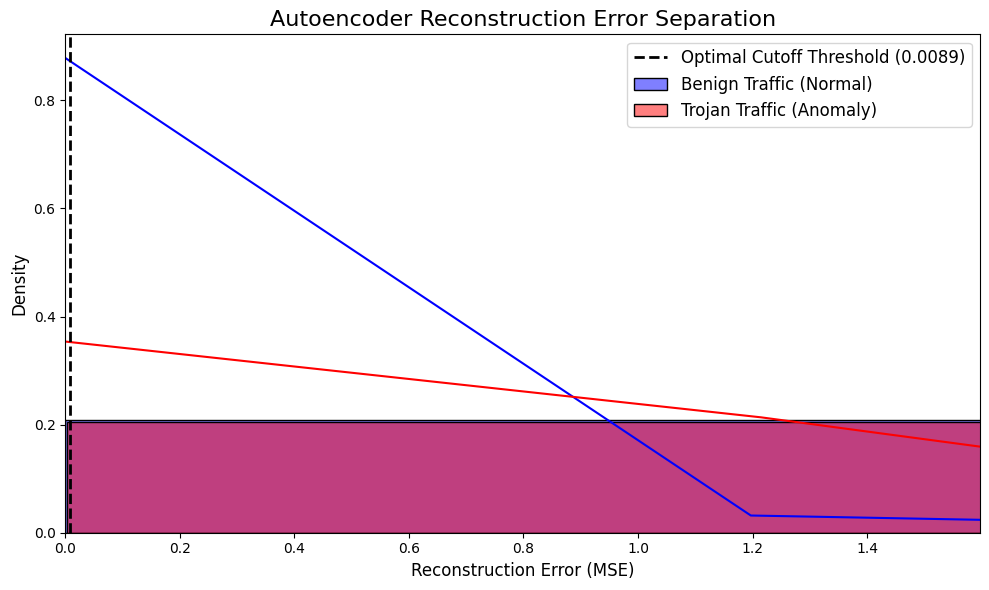

In [25]:
from sklearn.metrics import roc_curve

print("\nTraining Autoencoder on individual rows...")
X_train_benign = X_train_flat[y_train == 0]

ae_model = build_ae(X_train_flat.shape[1])
ae_model.fit(X_train_benign, X_train_benign, validation_split=0.1, epochs=15, batch_size=128, verbose=0)

# 1. Get raw MSE scores for the test set
reconstructions = ae_model.predict(X_test_flat, verbose=0)
ae_mse = np.mean(np.power(X_test_flat - reconstructions, 2), axis=1)

# 2. Mathematically find the optimal threshold using the ROC curve (Youden's J statistic)
fpr, tpr, thresholds = roc_curve(y_test, ae_mse)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]

print(f"Optimal Anomaly Threshold calculated at: {optimal_threshold:.6f}")

# 3. Scale the MSE so that the optimal_threshold maps EXACTLY to 0.5. 
# This makes our universal evaluate_model function calculate Accuracy/F1 correctly!
ae_probs = ae_mse / (2 * optimal_threshold)
ae_probs = np.clip(ae_probs, 0, 1)

evaluate_model("Autoencoder", y_test, ae_probs, X_test_flat, ae_model, is_dl=True, is_ae=True)

plot_autoencoder_errors(y_test, ae_mse, optimal_threshold)

# 8. Statistical Validation for LightGBM and XGBoost (Comment 7)

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as st
from sklearn.metrics import roc_auc_score, roc_curve
from lightgbm import LGBMClassifier

def statistical_validation_ml(model_class, model_kwargs, X_train, y_train, X_test, y_test, runs=5, title="LightGBM"):
    """
    Runs statistical validation for ML models and generates visualizations.
    """
    print(f"\n--- Statistical Validation ({title} - {runs} Runs) ---")
    aucs = []
    
    # Variables to track ROC curves for plotting
    tprs = []
    mean_fpr = np.linspace(0, 1, 100)
    
    # Initialize the plot (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    for i in range(runs):
        # 1. Instantiate model with a new random seed for each run
        kwargs = model_kwargs.copy()
        kwargs['random_state'] = i
        model = model_class(**kwargs)
        
        # 2. Train and predict
        model.fit(X_train, y_train)
        probs = model.predict_proba(X_test)[:, 1]
        
        # 3. Calculate AUC
        run_auc = roc_auc_score(y_test, probs)
        aucs.append(run_auc)
        
        # 4. Calculate ROC curve for this specific run
        fpr, tpr, _ = roc_curve(y_test, probs)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        
        # Plot individual run ROC (faint blue lines)
        ax1.plot(fpr, tpr, color='royalblue', alpha=0.15)

    # Calculate aggregate statistics
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    ci = st.t.interval(0.95, df=len(aucs)-1, loc=mean_auc, scale=st.sem(aucs))
    
    print(f"Mean AUC: {mean_auc:.6f} ± {std_auc:.6f}")
    print(f"95% Confidence Interval: [{ci[0]:.6f}, {ci[1]:.6f}]")
    
    # ==========================================
    # VISUALIZATION 1: Mean ROC with Confidence Band
    # ==========================================
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    
    # Plot Mean ROC
    ax1.plot(mean_fpr, mean_tpr, color='darkblue', label=f'Mean ROC (AUC = {mean_auc:.4f})', lw=2)
    ax1.plot([0, 1], [0, 1], linestyle='--', lw=2, color='red', label='Random Guess', alpha=0.8)
    
    # Plot 95% Confidence Band around the ROC curve
    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + 1.96 * std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - 1.96 * std_tpr, 0)
    ax1.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=0.2, label=r'$\pm$ 95% CI Band')
    
    ax1.set_xlabel('False Positive Rate', fontsize=12)
    ax1.set_ylabel('True Positive Rate', fontsize=12)
    ax1.set_title(f'{title} - ROC Curves over {runs} Runs', fontsize=14)
    ax1.legend(loc="lower right")
    
    # ==========================================
    # VISUALIZATION 2: Distribution of AUC Scores
    # ==========================================
    # Boxplot shows median and quartiles, Swarmplot shows exact individual scores
    sns.boxplot(y=aucs, ax=ax2, color='lightblue', width=0.3, fliersize=0)
    sns.swarmplot(y=aucs, ax=ax2, color='darkblue', alpha=0.8, size=8)
    
    ax2.set_title(f'Distribution of AUC-ROC Scores', fontsize=14)
    ax2.set_ylabel('AUC-ROC Score', fontsize=12)
    
    # Add an annotation box with the final metrics
    textstr = '\n'.join((
        f'Mean AUC: {mean_auc:.5f}',
        f'Std Dev:   {std_auc:.5f}',
        f'95% CI:    [{ci[0]:.5f}, {ci[1]:.5f}]'
    ))
    props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    ax2.text(0.05, 0.05, textstr, transform=ax2.transAxes, fontsize=12,
             verticalalignment='bottom', bbox=props)
    
    # Adjust layout and render
    plt.tight_layout()
    plt.show()

    return aucs


--- Statistical Validation (LightGBM - 5 Runs) ---
[LightGBM] [Info] Number of positive: 72526, number of negative: 69459
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018541 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7644
[LightGBM] [Info] Number of data points in the train set: 141985, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.510800 -> initscore=0.043208
[LightGBM] [Info] Start training from score 0.043208
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

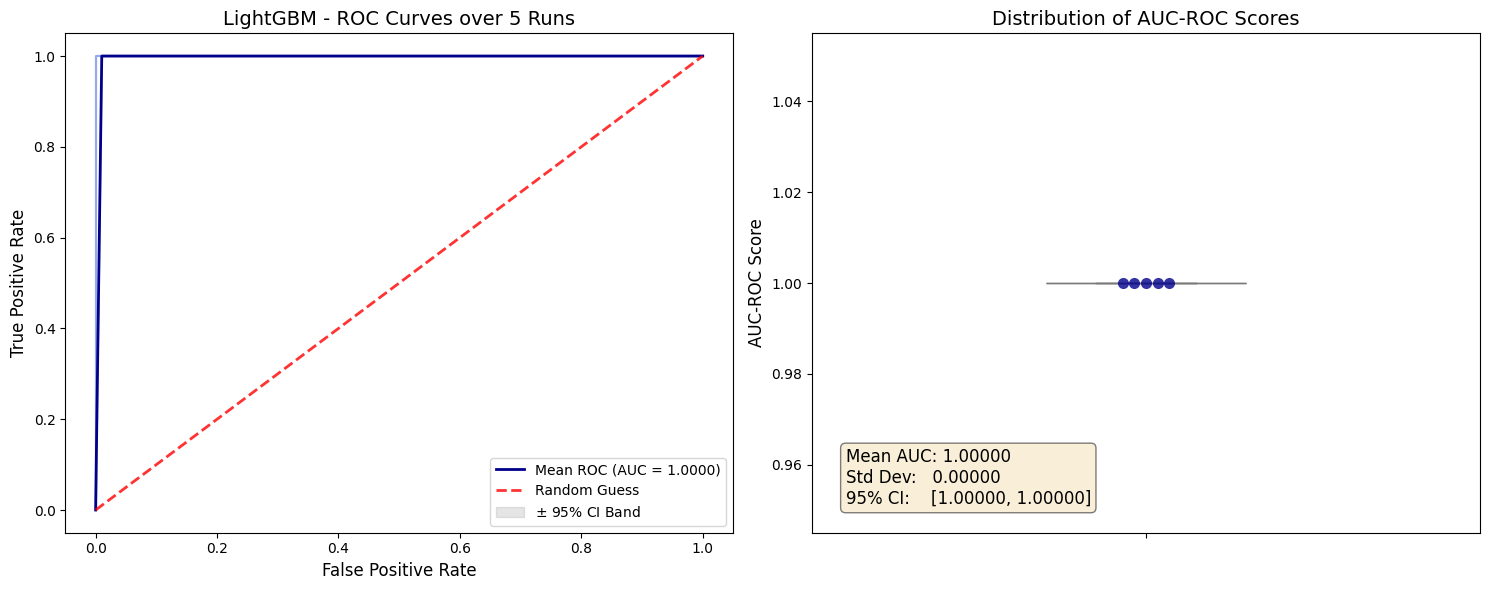

In [21]:
lgbm_params = {
    'n_estimators': 200, 
    'learning_rate': 0.05, 
    'n_jobs': -1
}

# Run the validation and visualize
aucs_lgbm = statistical_validation_ml(
    model_class=LGBMClassifier, 
    model_kwargs=lgbm_params, 
    X_train=X_train_flat, 
    y_train=y_train, 
    X_test=X_test_flat, 
    y_test=y_test, 
    runs=5, 
    title="LightGBM"
)


--- Statistical Validation (XGBoost - 5 Runs) ---
Mean AUC: 1.000000 ± 0.000000
95% Confidence Interval: [1.000000, 1.000000]


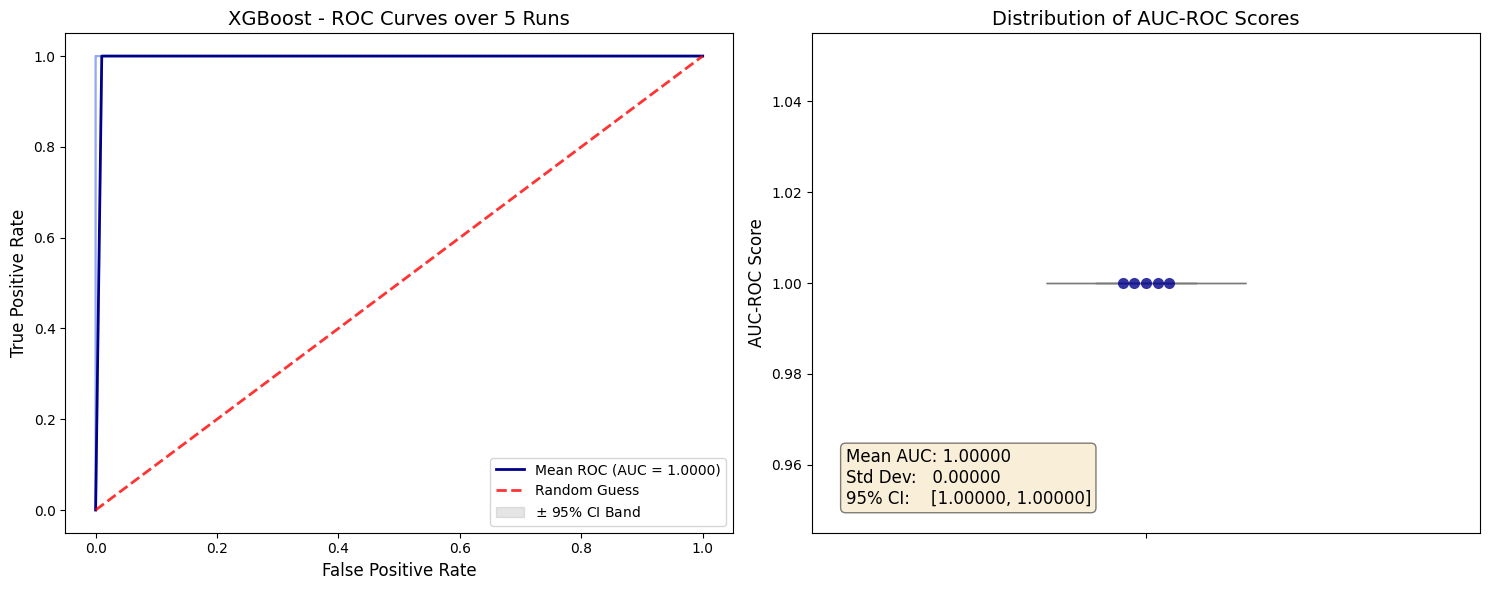

In [22]:
from xgboost import XGBClassifier

xgb_params = {
    'n_estimators': 200, 
    'learning_rate': 0.05, 
    'eval_metric': 'logloss',
    'n_jobs': -1
}

aucs_xgb = statistical_validation_ml(
    model_class=XGBClassifier, 
    model_kwargs=xgb_params, 
    X_train=X_train_flat, 
    y_train=y_train, 
    X_test=X_test_flat, 
    y_test=y_test, 
    runs=5, 
    title="XGBoost"
)

In [ ]:
# Capture the training history
history_tcn = tcn_model.fit(X_train_dl, y_train, validation_split=0.1, epochs=15, batch_size=128, verbose=0)

# (Keep your evaluate_model line here)

# Add this to the very bottom to draw the graphs!
plot_tcn_results(history_tcn, y_test, tcn_probs)